<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/ai/02_machine_learning/supervised/classification/experiment_naive_bayes_multiclass_roc_iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier


#-----------------------------
# Step 1: Load Dataset
#-----------------------------
iris = load_iris()
X = iris.data
y = iris.target
class_names = iris.target_names


In [ ]:
#-----------------------------
# Step 2: Train Test Split
#-----------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)



In [ ]:
#-----------------------------
# Step 3: Train Naive Bayes Model
#-----------------------------
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

In [ ]:
#-----------------------------
# Step 4: Prediction & Evaluation
#-----------------------------
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=class_names))

Accuracy: 0.9777777777777777

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      0.92      0.96        13
   virginica       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



In [ ]:
#-----------------------------
# Step 5: ROC & AUC (Multiclass)
#-----------------------------

#Binarize output for multiclass ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# One vs Rest classifier
classifier = OneVsRestClassifier(GaussianNB())
y_score = classifier.fit(X_train, y_train).predict_proba(X_test)

# Compute ROC curve and AUC for each class
fpr=dict()
tpr=dict()
roc_auc=dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

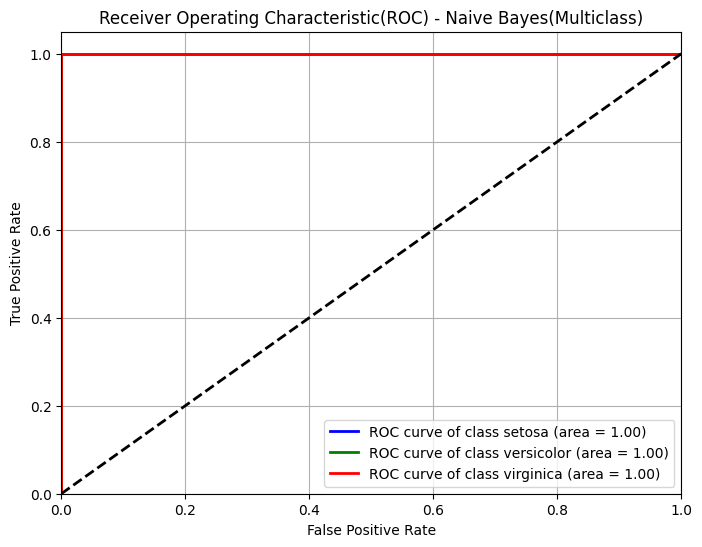

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
colors = ['blue','green','red']

for i, color in zip(range(n_classes), colors):
    plt.plot(
        fpr[i],
        tpr[i],
        color=color,
        lw = 2,
        label = f'ROC curve of class {class_names[i]} (area = {roc_auc[i]:.2f})'
    )

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic(ROC) - Naive Bayes(Multiclass)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()